In [203]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [204]:
#set global seaborn theme
sns.set_theme(style='whitegrid')

**DATA EXPLORATION**

In [205]:
tips = sns.load_dataset('tips')

In [206]:
print(f'first view of dataset: \n{tips.head()}')

first view of dataset: 
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [207]:
print(f'Shape of the dataset: {tips.shape}')
print("\n Data Types: \n", tips.dtypes)
print("\nMissing Values: \n", tips.isnull().sum())

Shape of the dataset: (244, 7)

 Data Types: 
 total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Missing Values: 
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [208]:
#Converting day column into ordered categories
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
tips['day'] = pd.Categorical(tips['day'], categories=day_order, ordered= True)
print("\n Ordered 'day categorical:", tips['day'].cat.categories)


 Ordered 'day categorical: Index(['Thur', 'Fri', 'Sat', 'Sun'], dtype='object')


In [209]:
tips['tip_percent'] = (tips['tip']/tips['total_bill']) * 100

bins = [-np.inf, 10, 20, np.inf]
labels = ['Low', 'Medium', "High"]
tips['tip_category'] = pd.cut(tips['tip_percent'], bins=bins, labels=labels)

print('\n Sample Data with New Features: \n', tips[['total_bill', 'tip', 'tip_percent', 'tip_category']].head())


 Sample Data with New Features: 
    total_bill   tip  tip_percent tip_category
0       16.99  1.01     5.944673          Low
1       10.34  1.66    16.054159       Medium
2       21.01  3.50    16.658734       Medium
3       23.68  3.31    13.978041       Medium
4       24.59  3.61    14.680765       Medium


**CATEGORICAL ANALYSIS**

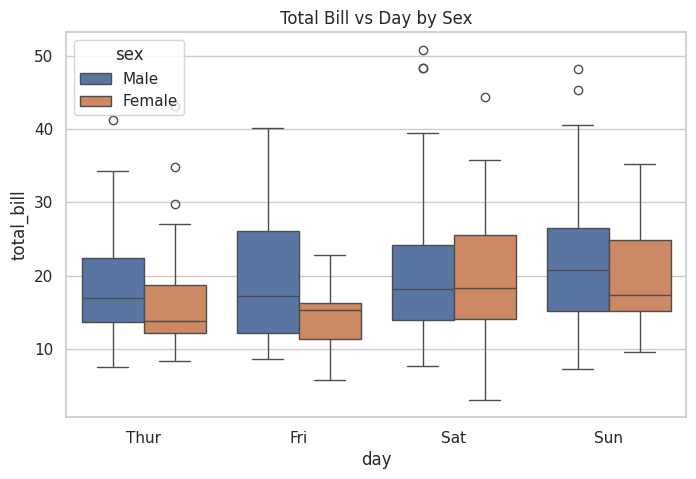

In [210]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex')
plt.title('Total Bill vs Day by Sex')
plt.savefig('Total Bill vs Day by Sex', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Observations:
*   Highest Median Bill Day: Sunday (Saturday for Females, Sunday for males)
*   Males generally show higher variability (wider IQR and higher range)



In [211]:
#Outlier Detection Task
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR =  Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 - 1.5*IQR
outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"\n Outliers detected using IQR method ({len(outliers)} rows): \n\n", outliers[['total_bill', 'tip', 'day', 'sex']])


 Outliers detected using IQR method (237 rows): 

      total_bill   tip   day     sex
0         16.99  1.01   Sun  Female
1         10.34  1.66   Sun    Male
2         21.01  3.50   Sun    Male
3         23.68  3.31   Sun    Male
4         24.59  3.61   Sun  Female
..          ...   ...   ...     ...
239       29.03  5.92   Sat    Male
240       27.18  2.00   Sat  Female
241       22.67  2.00   Sat    Male
242       17.82  1.75   Sat    Male
243       18.78  3.00  Thur  Female

[237 rows x 4 columns]


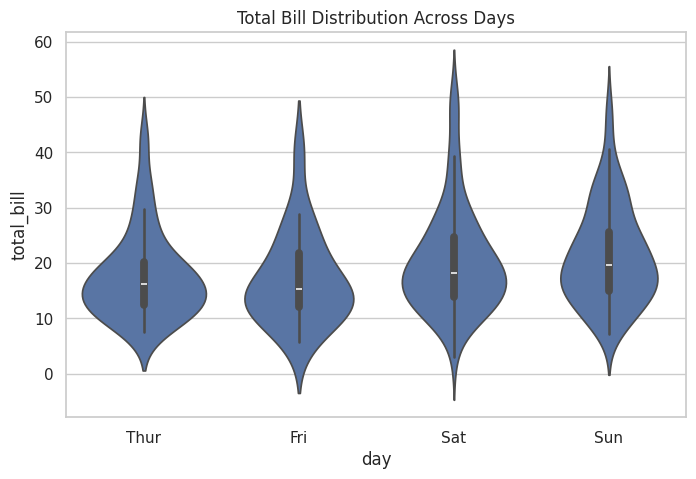

In [212]:
#Violin Plot Insight
plt.figure(figsize=(8, 5))
sns.violinplot(data=tips, x='day', y='total_bill')
plt.title("Total Bill Distribution Across Days")
plt.savefig('Total Bill Distribution Across Days', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Sunday/Saturday often show slight bimodal distributions (multiple peaks indicating clusters of smaller and larger bills)

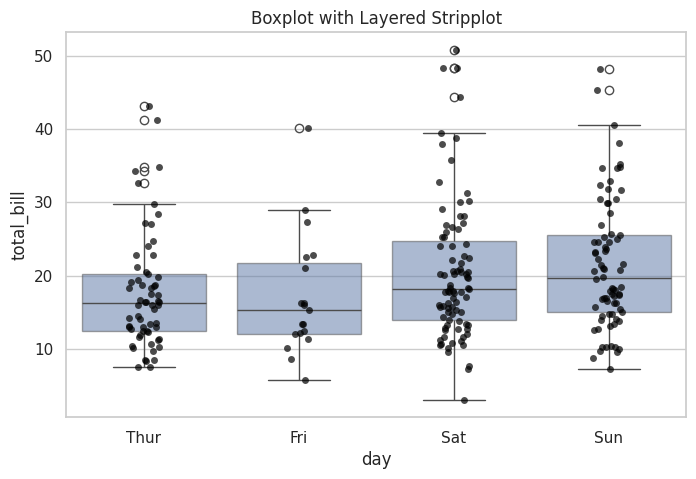

In [213]:
#Strip + Box Combination
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x='day', y='total_bill', boxprops=dict(alpha=0.5))
sns.stripplot(data=tips, x='day', y='total_bill', jitter=True, color='black', alpha=0.7)
plt.title('Boxplot with Layered Stripplot')
plt.savefig('Boxplot with Layered Stripplot', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

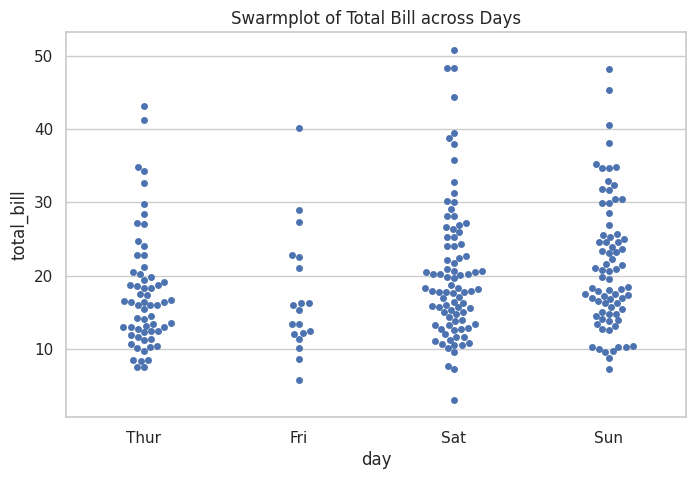

In [214]:
#Swarmplot Density Study
plt.figure(figsize=(8, 5))
sns.swarmplot(data=tips, x='day', y='total_bill')
plt.title('Swarmplot of Total Bill across Days')
plt.savefig('Swarmplot of Total Bill across Days', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Saturday has the highest data density (most points closely clustered together).

**STATISTICAL AGGREGATION**

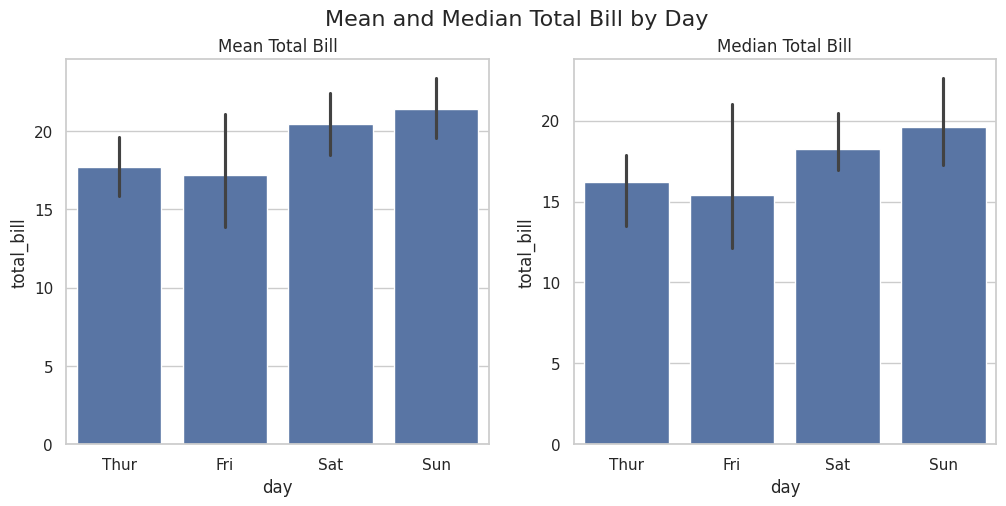

In [215]:
#Barplot with Custom Estimator
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle('Mean and Median Total Bill by Day', fontsize=16)
sns.barplot(data=tips, x='day', y='total_bill', estimator=np.mean, ax=axes[0])
axes[0].set_title('Mean Total Bill')

sns.barplot(data= tips, x='day', y='total_bill', estimator=np.median, ax=axes[1])
axes[1].set_title('Median Total Bill')

plt.savefig('Mean and Median Total Bill by Day', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

The median is lower than the mean because total_bill is right-skewed with the extreme high-value outliers pulling the mean up

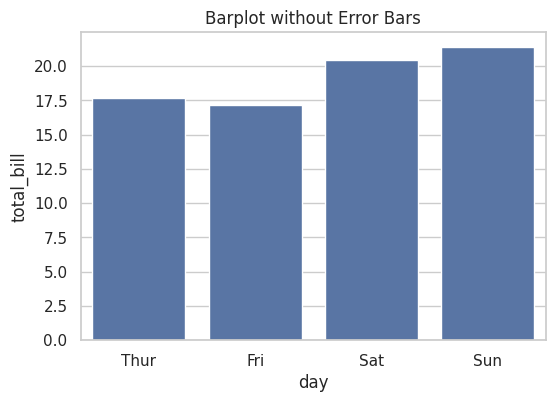

In [216]:
#Confidence Interval Understanding
plt.figure(figsize=(6, 4))
sns.barplot(data=tips, x='day', y='total_bill', errorbar=None)
plt.title('Barplot without Error Bars')
plt.savefig('Barplot without Error Bars', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Errors bars typically represent confidence intervals, indicating the uncertainity of the estimated means

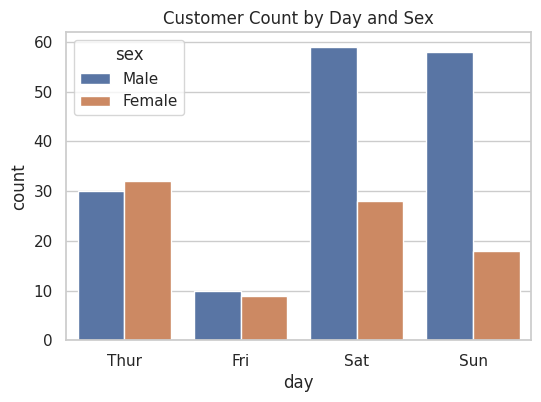

In [217]:
#Countplot Business Insight
plt.figure(figsize=(6, 4))
sns.countplot(data=tips, x='day', hue='sex')
plt.title('Customer Count by Day and Sex')
plt.savefig('Customer Count by Day and Sex', bbox_inches = 'tight', dpi=150, facecolor = 'white')
plt.show()

Saturday has the highest overall customer traffic

**INTERACTION EFFECTS**

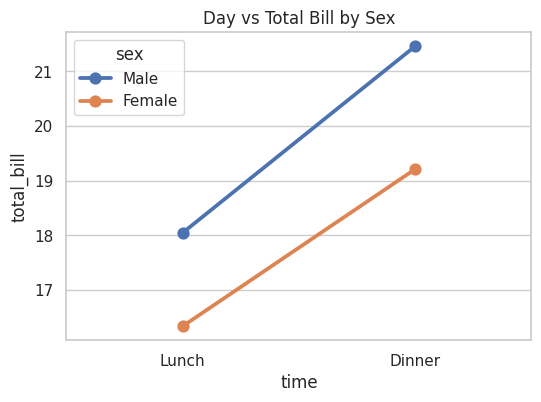

In [218]:
#Pointplot Interaction
plt.figure(figsize=(6, 4))
sns.pointplot(data=tips, x='time', y='total_bill', hue='sex', errorbar=None)
plt.title('Day vs Total Bill by Sex')
plt.savefig('Day vs Total Bill by Sex', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Since the lines are not parallel, therefore, the lines cross. This indicates an interaction effect between 'time' and 'sex' regarding total spending.

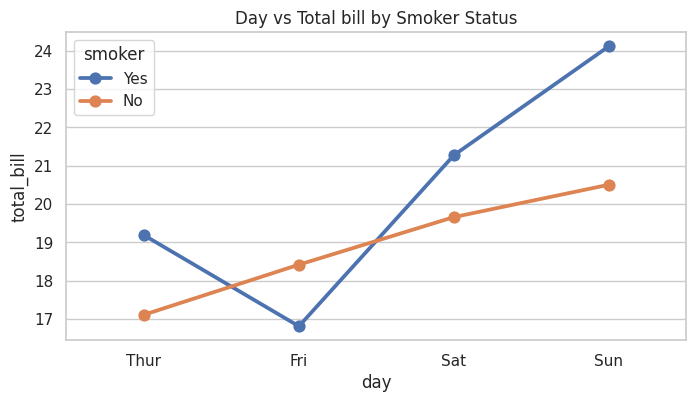

In [219]:
#Advanced Interaction
plt.figure(figsize=(8, 4))
sns.pointplot(data=tips, x='day', y='total_bill', hue='smoker', errorbar=None)
plt.title('Day vs Total bill by Smoker Status')
plt.savefig('Day vs Total bill by Smoker Status', bbox_inches = 'tight', dpi=150, facecolor='white')
plt.show()

Smokers and Non-Smokers show differing trends depending on the day. Specifically, smokers spend significantly more on weekends compared to weekdays

**DISTRIBUTION ANALYSIS**

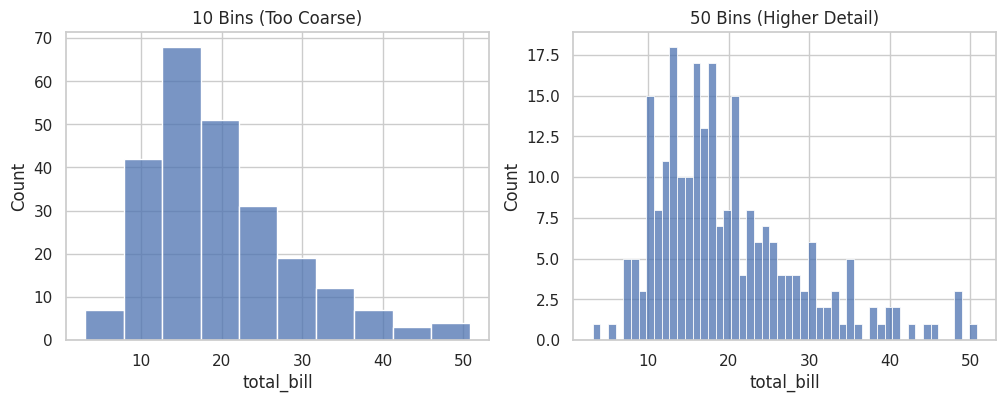

In [220]:
#Histogram Tuning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(tips['total_bill'], bins=10, ax= axes[0])
axes[0].set_title('10 Bins (Too Coarse)')
sns.histplot(tips['total_bill'], bins=50, ax=axes[1])
axes[1].set_title('50 Bins (Higher Detail)')
plt.savefig('Histogram Comparison', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Around 20-30 bins usually balance noisy detail and over-smoothing. Bins=10 hides sub-patterns, where Bins=50 can be overly noisy.

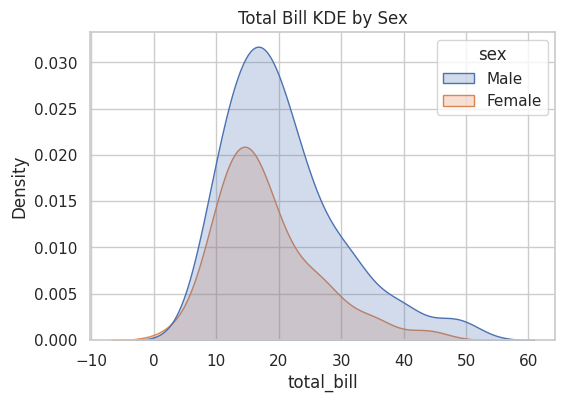

In [221]:
#KDE Analysis
plt.figure(figsize=(6, 4))
sns.kdeplot(data=tips, x='total_bill', hue='sex', fill=True)
plt.title('Total Bill KDE by Sex')
plt.savefig('Total Bill KDE by Sex', dpi= 150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Male customers have a sdistribution shifted slightly to the right (higher average bill and longer tail).

Skewness of total_bill: 1.1332 



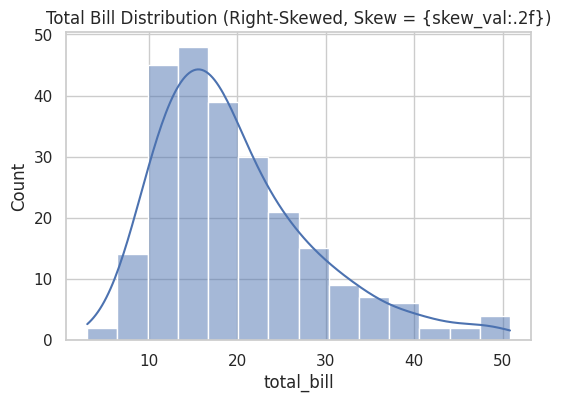

In [222]:
#Skewness Detection
skew_val = tips['total_bill'].skew()
print(f'Skewness of total_bill: {skew_val:.4f} \n')
plt.figure(figsize=(6, 4))
sns.histplot(tips['total_bill'], kde=True)
plt.title('Total Bill Distribution (Right-Skewed, Skew = {skew_val:.2f})')
plt.savefig('Total Bill Distribution (Right-Skewed)', dpi=150, bbox_inches='tight', facecolor = 'white')
plt.show()

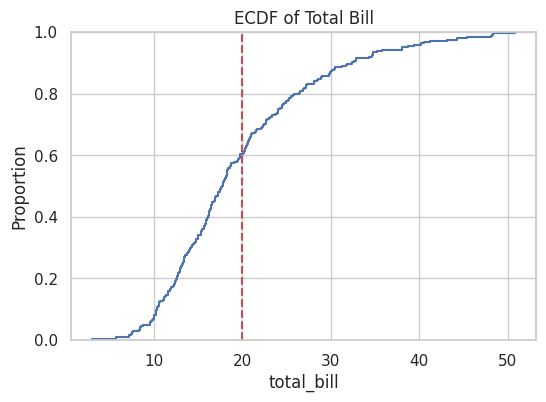

Percentage of Bills < $20:  60.25%
Probabilty that bill > $40:  0.0410 (or (prob_over_40*100:.2f))


In [223]:
#ECDF Analysis
plt.figure(figsize=(6, 4))
sns.ecdfplot(data=tips, x='total_bill')
plt.axvline(20, color='r', linestyle='--')
plt.title('ECDF of Total Bill')
plt.savefig('ECDF of Total Bill', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

pct_under_20 = (tips['total_bill'] < 20).mean() * 100
print(f"Percentage of Bills < $20: {pct_under_20: .2f}%")

prob_over_40 = (tips['total_bill'] > 40).mean()
print(f"Probabilty that bill > $40: {prob_over_40: .4f} (or (prob_over_40*100:.2f))")

**MULTIVARIATE ANALYSIS**

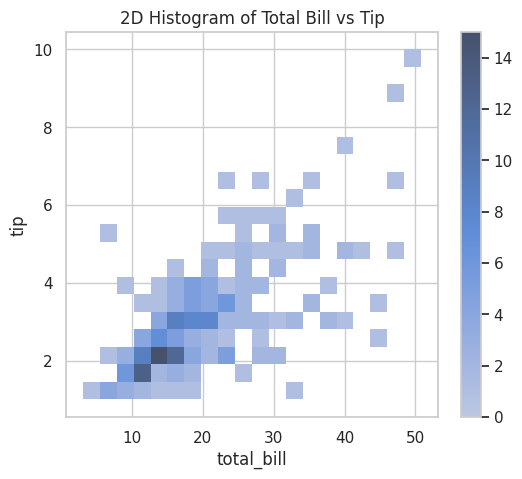

In [224]:
# 2D Histogram
plt.figure(figsize=(6, 5))
sns.histplot(data=tips, x='total_bill', y='tip', bins=20, cbar=True)
plt.title('2D Histogram of Total Bill vs Tip')
plt.savefig('2D Histogram of Total Bill vs Tip', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

There is a positive correlation between total bill and tip

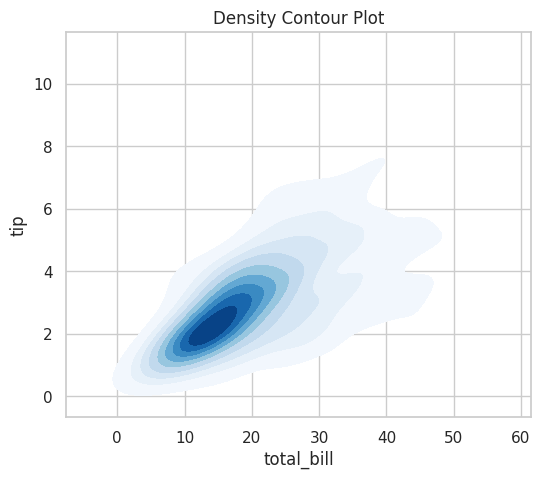

In [225]:
#KDE Contour Plot
plt.figure(figsize=(6, 5))
sns.kdeplot(data=tips, x='total_bill', y='tip', fill=True, cmap='Blues')
plt.title('Density Contour Plot')
plt.savefig('Density Contour Plot', facecolor = 'white', dpi=150, bbox_inches='tight')
plt.show()

Highest density region lies arounf total_bill = $12 - $18 and tip = $2 - $3.

**ADVANCED CATPLOT**

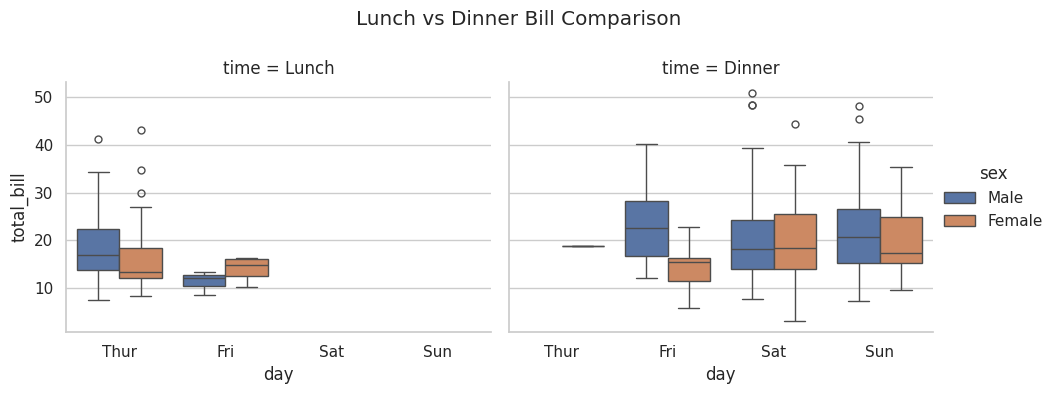

In [226]:
g = sns.catplot(data=tips, x='day', y='total_bill', hue='sex', col='time', kind='box', height=4, aspect=1.2)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Lunch vs Dinner Bill Comparison')
plt.savefig('Lunch vs Dinner Bill Comparison', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.show()

Lunch has significantly lower total bills with less variance, mostly restricted to Thursdays. Dinner (weekends) features higher median bills and broader variance.

**BUSINESS STRATEGY SOLUTION**

Insights and Plots Genrated below:


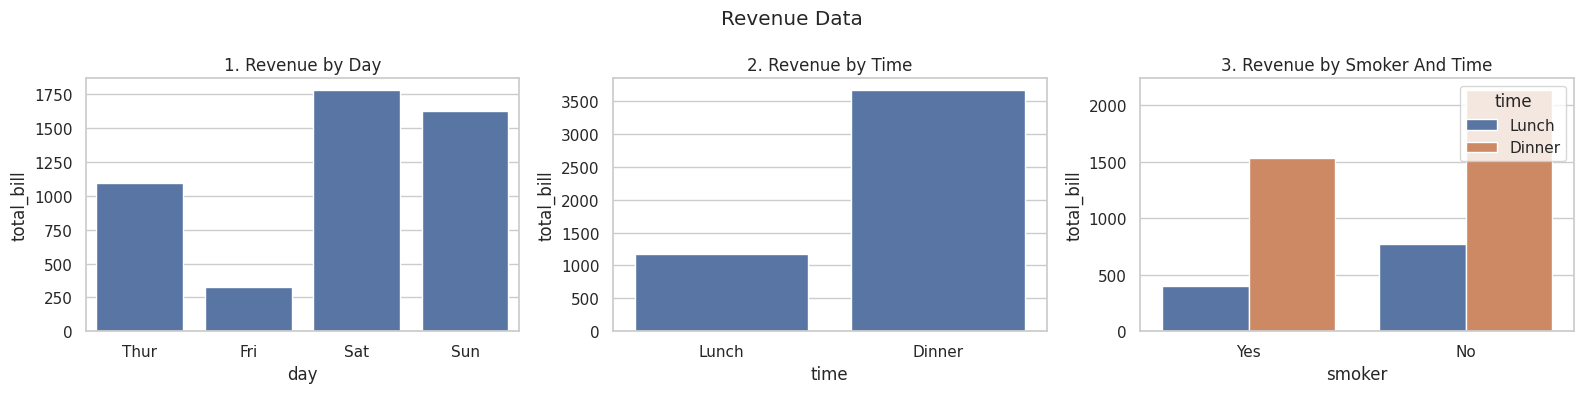

In [227]:
#Insights and Plots Generated
print("Insights and Plots Genrated below:")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle('Revenue Data')
sns.barplot(data=tips, x='day', y='total_bill', ax=axes[0], estimator=np.sum, errorbar=None)
axes[0].set_title('1. Revenue by Day')

sns.barplot(data=tips, x='time', y='total_bill', ax=axes[1], estimator=np.sum, errorbar=None)
axes[1].set_title('2. Revenue by Time')

sns.barplot(data=tips, x='smoker', y='total_bill', hue='time', ax=axes[2], estimator=np.sum, errorbar=None)
axes[2].set_title('3. Revenue by Smoker And Time')
plt.savefig('Revenue Data', dpi=150, bbox_inches = 'tight', facecolor = 'white')
plt.tight_layout()
plt.show()

*   Saturday and Sunday generate the highest total revenue due to both volume and larger check sizes
*   Dinner accounts for the vast  majority of revenue
*   Non - Smokers bring in the higher overall total volume, though party sizes during weekend dinner are primary targets.
*   Recommendation: Target weekend dinner crowds, promoting high-margin items to large dining groups.

Automated EDA Pipeline
Dataset Shape (cleaned): (243, 10)



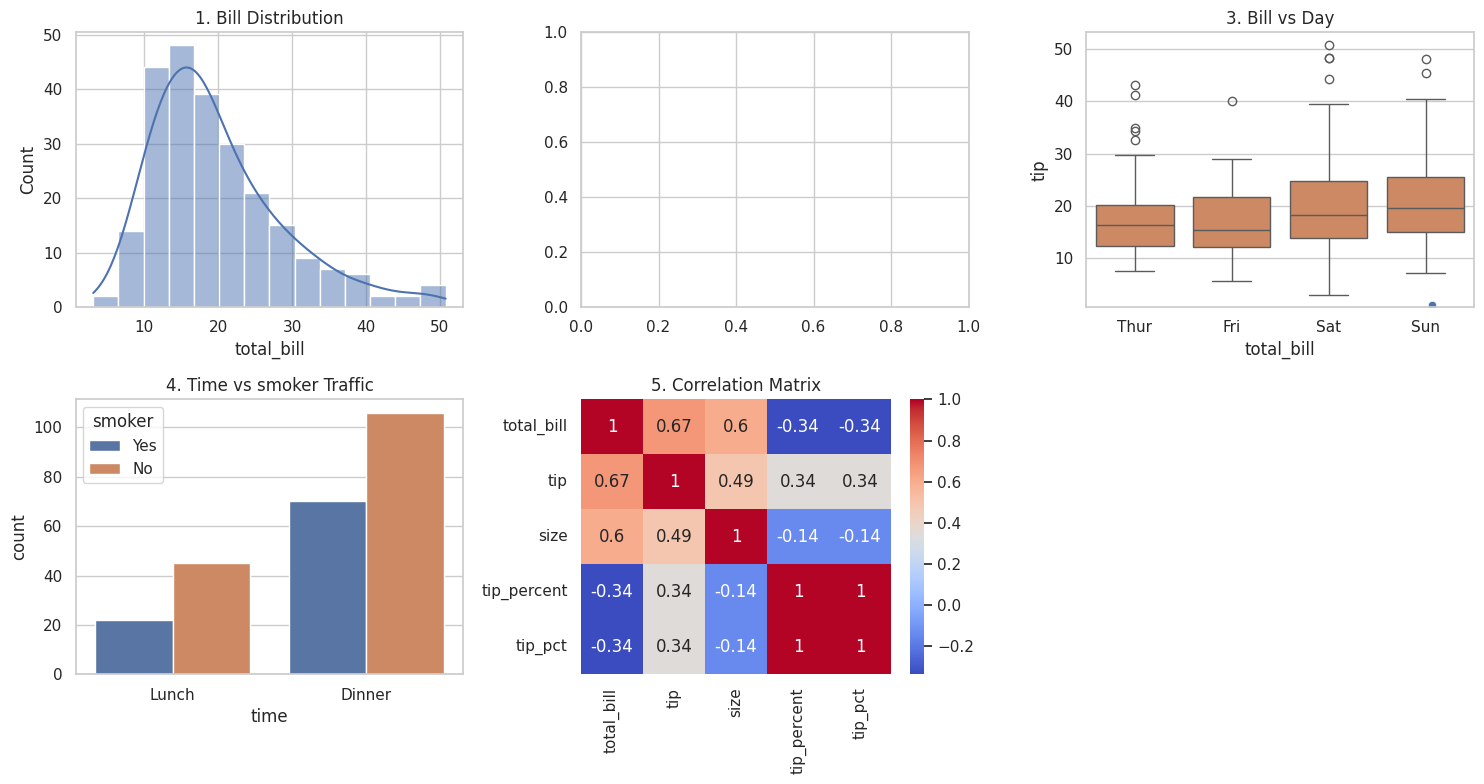

Pipeline Execution Completed Successfully.


In [230]:
#Exploratory Dataset Analysis Pipeline Function

def analyse_dataset(df):
    #Automated EDA function performing data cleaning, feature engineering, visualisation, and printed summary statistics.

    print("Automated EDA Pipeline")

    df_clean = df.dropna().drop_duplicates().copy()

    #Feature Engineering
    if 'total_bill' in df_clean.columns and 'tip' in df_clean.columns:
        df_clean['tip_pct'] = (df_clean['tip'] / df_clean['total_bill']) * 100

    print(f"Dataset Shape (cleaned): {df_clean.shape}\n")

    #Visualisations
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    #Visualisation 1: Histogram
    sns.histplot(df_clean['total_bill'], kde=True, ax=axes[0,0])
    axes[0, 0].set_title('1. Bill Distribution')

    #Visualisation 2: Scatter
    sns.scatterplot(data=df_clean, x='total_bill', y='tip', ax=axes[0, 2])
    axes[0, 2].set_title('2. Bill vs Tip')

    #Visualisation 3: Boxplot
    sns.boxplot(data=df_clean, x='day', y='total_bill', ax=axes[0, 2])
    axes[0,2].set_title('3. Bill vs Day')

    #Visualplot 4: Countplot
    sns.countplot(data=df_clean, x='time', hue='smoker', ax=axes[1, 0])
    axes[1, 0].set_title('4. Time vs smoker Traffic')

    #Visualisation 5: Heatmap / Correlation
    num_df = df_clean.select_dtypes(include=[np.number])
    sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('5. Correlation Matrix')

    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig('Automated EDA Pipeline', dpi=150, bbox_inches = 'tight', facecolor = 'white')
    plt.show()

    print('Pipeline Execution Completed Successfully.')

analyse_dataset(tips)